In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 10)
pd.options.display.float_format = '{:.2f}'.format
sns.set()

In [50]:
#1. Get data

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')
df_train.head()

train = df_train.to_numpy()
test = df_test.to_numpy()
train

array([[2, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       ...,
       [8, 0, 0, ..., 0, 0, 0],
       [8, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [51]:
ms = train.shape[0]
ns = train.shape[1]
mt, nt = test.shape

X_train = train[:,1:ns]
X_train = (X_train.T)/255
y_train = train[:,0]
X_test = test[:,1:nt]
X_test = (X_test.T)/255
y_test = test[:,0]
X_train

# Network architecture
neur1 = 128
neur2 = 64
neur3 = 10  # Output layer

m = X_train.shape[1]   #number of training examples
n = X_train.shape[0]   #number of features (pixels)

In [52]:
# Dataset Distribution

In [53]:
def kaimingInitialization():
    W1 = np.random.randn(neur1, n) * np.sqrt(2. / n)
    b1 = np.zeros((neur1, 1))
    W2 = np.random.randn(neur2, neur1) * np.sqrt(2. / neur1)
    b2 = np.zeros((neur2, 1))
    W3 = np.random.randn(neur3, neur2) * np.sqrt(2. / neur2)
    b3 = np.zeros((neur3, 1))
    
    return W1, b1, W2, b2, W3, b3


In [54]:
#Activation Functions
def ReLU(z):
    return np.maximum(z,0)

def dReLU(z):
    return z>0

def LeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, vector, alpha * vector)

def dLeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, 1, alpha)

def softmax(vector):
    vector = np.array(vector)
    e_x = np.exp(vector - np.max(vector, axis=0, keepdims=True))
    return e_x / e_x.sum(axis=0, keepdims=True)

def dSoftmax(vector):
    vector = np.array(vector)
    s = softmax(vector)
    return np.diagflat(s) - np.outer(s, s)

def tanh(vector):
    vector = np.array(vector)
    return np.tanh(vector)

def dTanh(vector):
    vector = np.array(vector)
    return 1 - np.tanh(vector)**2

def sigmoid(vector):
    vector = np.array(vector)
    return 1 / (1 + np.exp(-vector))

def dSigmoid(vector):
    vector = np.array(vector)
    s = sigmoid(vector)
    return s * (1 - s)


In [1]:
#Apply dropout
def dropout(A, dropout_rate):
    mask = np.random.rand(*A.shape) > dropout_rate  # Create a mask with probability (1 - dropout_rate)
    A_dropout = A * mask / (1 - dropout_rate)  # Apply mask and scale the activations
    return A_dropout, mask

In [55]:
# One-Hot Encoding
def one_hot(Y):
    init_one = np.zeros((neur3, m))
    init_one[Y[np.arange(m)], np.arange(m)] = 1
    return init_one

In [56]:
# # Forward Propagation
# def forward_pass(W1, b1, W2, b2, W3, b3, X):
#     Z1 = W1.dot(X) + b1
#     A1 = sigmoid(Z1)
#     Z2 = W2.dot(A1) + b2
#     A2 = sigmoid(Z2)
#     Z3 = W3.dot(A2) + b3
#     A3 = softmax(Z3)
#     return Z1, A1, Z2, A2, Z3, A3

In [ ]:
# Forward propagation with dropout
def forward_propagation_with_dropout(X, W1, B1, W2, B2, dropout_rate):
    Z1 = np.dot(W1, X) + B1
    A1 = tanh(Z1)
    A1_dropout, mask1 = dropout(A1, dropout_rate)  # Apply dropout to the first layer activations
    Z2 = np.dot(W2, A1_dropout) + B2
    A2 = softmax(Z2)
    return Z1, A1, A1_dropout, mask1, Z2, A2  # Return all intermediate values including dropout mask

In [57]:
# # Backward Propagation
# def crossentropy_backpropagation(Z1, A1, Z2, A2, Z3, A3, W3, W2, X, y):
#     Y_one_hot = one_hot(y)
    
#     dL_dZ3 = A3 - Y_one_hot
#     dL_db3 = (1 / m) * (np.sum(dL_dZ3, axis=1).reshape(neur3, 1))
#     dL_dW3 = (1 / m) * (dL_dZ3.dot(A2.T))
    
#     dL_dZ2 = W3.T.dot(dL_dZ3) * dSigmoid(Z2)
#     dL_db2 = (1 / m) * (np.sum(dL_dZ2, axis=1).reshape(neur2, 1))
#     dL_dW2 = (1 / m) * (dL_dZ2.dot(A1.T))
    
#     dL_dZ1 = W2.T.dot(dL_dZ2) * dSigmoid(Z1)
#     dL_db1 = (1 / m) * (np.sum(dL_dZ1, axis=1).reshape(neur1, 1))
#     dL_dW1 = (1 / m) * (dL_dZ1.dot(X.T))
    
#     return dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1

In [ ]:
def backward_propagation_with_dropout(X_train, y_train, Z1, A1, A1_dropout, Z2, A2, W1, W2, mask1, dropout_rate):
    m = X_train.shape[1]  # Number of examples
    
    # Backward propagation through the output layer
    dZ2 = A2 - y_train  # Derivative of the loss w.r.t Z2 (cross-entropy loss with softmax)
    dW2 = 1/m * np.dot(dZ2, A1_dropout.T)
    dB2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
    
    # Backward propagation through the hidden layer
    dA1_dropout = np.dot(W2.T, dZ2)  # Gradient w.r.t A1_dropout
    dA1 = dA1_dropout * mask1 / (1 - dropout_rate)  # Adjust for dropout scaling
    dZ1 = dA1 * dLeakyReLU(Z1)  # Element-wise multiplication with the derivative of Leaky ReLU
    dW1 = 1/m * np.dot(dZ1, X_train.T)
    dB1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, dB1, dW2, dB2

In [58]:
# Update Parameters
def update_parameters(W1, b1, W2, b2, W3, b3, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, alpha):
    W1 -= alpha * dL_dW1
    b1 -= alpha * dL_db1
    W2 -= alpha * dL_dW2
    b2 -= alpha * dL_db2
    W3 -= alpha * dL_dW3
    b3 -= alpha * dL_db3
    return W1, b1, W2, b2, W3, b3

In [59]:
# Predictions
def get_predictions(A3):
    return np.argmax(A3, 0)


In [60]:
#Accuracy
def get_accuracy(predictions,y):
    print(predictions,y)
    return np.sum(predictions == y)/y.size

In [61]:
def compute_loss(A3, Y):
    return -np.sum(Y * np.log(A3)) / m

In [62]:
# Gradient Descent
def gradient_descent(X, y, epochs, alpha):
    W1, b1, W2, b2, W3, b3 = kaimingInitialization()

    accuracy_scores = []
    loss_list = []
    
    for i in range(epochs):
        Z1, A1, Z2, A2, Z3, A3 = forward_propagation_with_dropout(W1, b1, W2, b2, W3, b3, X)
        
        loss = compute_loss(A3, one_hot(y))
        loss_list.append(loss)
        
        dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1 = backward_propagation_with_dropout(Z1, A1, Z2, A2, Z3, A3, W3, W2, X, y)
        
        W1, b1, W2, b2, W3, b3 = update_parameters(W1, b1, W2, b2, W3, b3, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, alpha)

        accuracy = get_accuracy(get_predictions(A3), y)
        accuracy_scores.append(accuracy)
        
        if i % 5 == 0:
            print("Iteration: ", i)
            print("Loss: ", loss)
            print("Accuracy: ", accuracy)
            print('*' * 20)
    
    return W1, b1, W2, b2, W3, b3, Z3, A3, accuracy_scores, loss_list


In [63]:
W1, b1, W2, b2, W3, b3, Z3, A3, accuracy, loss = gradient_descent(X_train, y_train, 501, 0.1)

[5 5 5 ... 5 4 4] [2 9 6 ... 8 8 7]
Iteration:  0
Loss:  2.586456101529943
Accuracy:  0.12741666666666668
********************
[5 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[5 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[5 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[5 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[4 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
Iteration:  5
Loss:  2.313339735120242
Accuracy:  0.15418333333333334
********************
[4 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[4 4 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[4 9 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[4 9 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[4 9 4 ... 5 4 4] [2 9 6 ... 8 8 7]
Iteration:  10
Loss:  2.2620440003818785
Accuracy:  0.3022
********************
[4 9 4 ... 5 4 4] [2 9 6 ... 8 8 7]
[4 9 4 ... 3 4 4] [2 9 6 ... 8 8 7]
[4 9 4 ... 3 4 4] [2 9 6 ... 8 8 7]
[4 9 4 ... 3 4 4] [2 9 6 ... 8 8 7]
[4 9 2 ... 3 4 7] [2 9 6 ... 8 8 7]
Iteration:  15
Loss:  2.2411431010313887
Accuracy:  0.3594
********************
[4 9 2 ... 3 4 7] [2 9 6 ... 8 8 7]
[4 9 2 ... 3 4 7] [2 9 6 ... 8 8 7]
[4 9 2 ...

In [64]:
# Validation
Z1, A1, Z2, A2, Z3, A3 = forward_pass(W1, b1, W2, b2, W3, b3, X_test)
print("Test Accuracy: ", get_accuracy(get_predictions(A3), y_test))


[0 1 2 ... 8 2 4] [0 1 2 ... 8 8 1]
Test Accuracy:  0.7194


In [65]:
def make_predictions(X, W1, b1, W2, b2, W3, b3):
    _, _, _, _, _, A3 = forward_pass(W1, b1, W2, b2, W3, b3, X)
    predictions = get_predictions(A3)
    return predictions

def test_prediction(index, W1, b1, W2, b2, W3, b3):
    current_image = X_test[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2, W3, b3)
    label = y_test[index]
    print('Prediction: ', prediction)
    print('Label: ', label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()


Prediction:  [5]
Label:  5


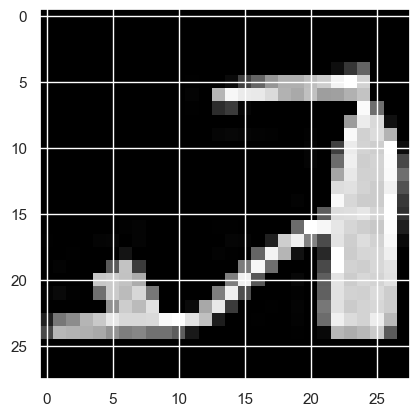

In [66]:
test_prediction(9800, W1, b1, W2, b2, W3, b3)

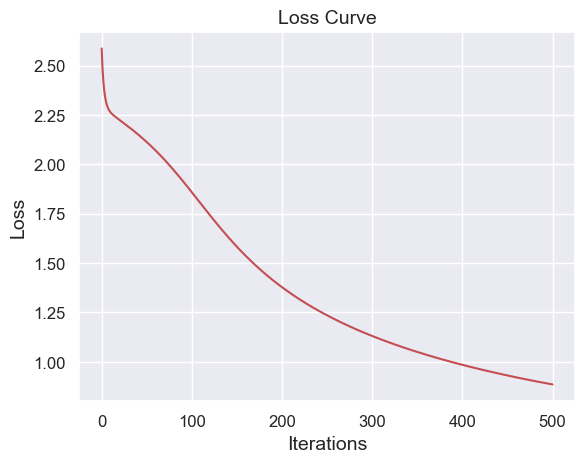

In [67]:
plt.plot(loss, linestyle='-', color='r')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Loss Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

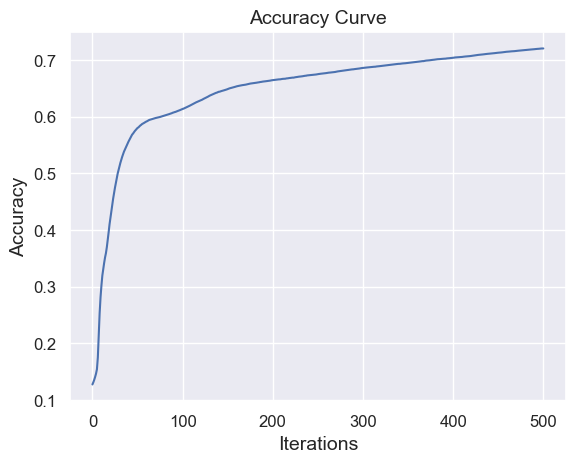

In [68]:
plt.plot(accuracy, linestyle='-', color='b')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Accuracy Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

In [69]:
predictions = get_predictions(A3)
predictions[67]

9

In [70]:
confusion = confusion_matrix(y_test, predictions)
print(confusion)

[[771   7  25 112   7  10  50   1  17   0]
 [ 10 920  18  34   3   1  14   0   0   0]
 [ 21   2 637   6 201   2 113   0  18   0]
 [ 74  30   7 839  18   2  29   0   1   0]
 [ 11   7 300  86 533   2  52   0   9   0]
 [  0   0   0   4   0 651   2 210  13 120]
 [250   4 255  64 189   2 202   0  33   1]
 [  0   0   0   0   0  55   0 838   0 107]
 [  2   1  30  36   3  19   8  12 887   2]
 [  0   0   0   0   0  16   0  67   1 916]]


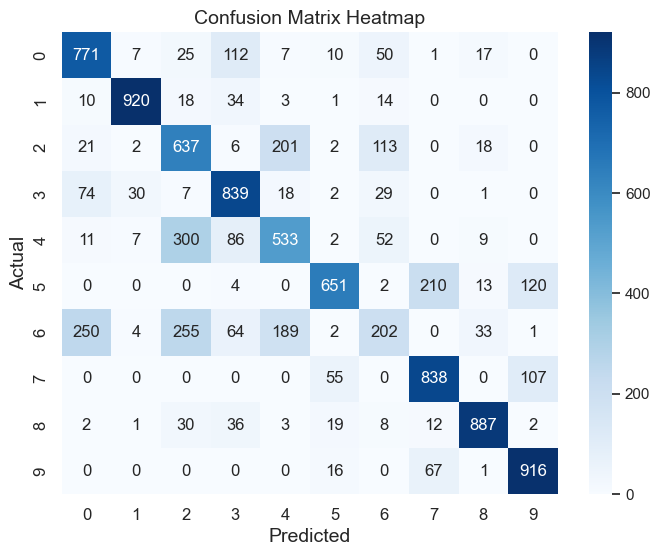

In [71]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [72]:
report = classification_report(y_test, predictions, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.68      0.77      0.72      1000
           1       0.95      0.92      0.93      1000
           2       0.50      0.64      0.56      1000
           3       0.71      0.84      0.77      1000
           4       0.56      0.53      0.55      1000
           5       0.86      0.65      0.74      1000
           6       0.43      0.20      0.27      1000
           7       0.74      0.84      0.79      1000
           8       0.91      0.89      0.90      1000
           9       0.80      0.92      0.85      1000

    accuracy                           0.72     10000
   macro avg       0.71      0.72      0.71     10000
weighted avg       0.71      0.72      0.71     10000

